# Model 2 Performance: Decision Tree
**CAP182 Capstone Project: STADIOEquities**

Evaluates the saved Model 2 on the unseen, later test period using metrics with 95% bootstrap confidence intervals, baselines, cross-validation stability, curves, a gains table, a threshold analysis, calibration and a robustness check.

Requires `models/model2_decision_tree.pkl`, `data/train.csv` and `data/test.csv` (run the feature engineering and Model 2 notebooks first).

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             classification_report, roc_auc_score)
from sklearn.calibration import calibration_curve

sys.path.append("..")
from utils.evaluation_utils import (bootstrap_metrics, gains_table, threshold_table,
                                    paired_bootstrap_difference, compute_metrics)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
X_train, y_train = train.drop(columns="y"), train["y"]
X_test, y_test = test.drop(columns="y"), test["y"]

model = joblib.load("../models/model2_decision_tree.pkl")
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print("Test period:", len(y_test), "customers,", int(y_test.sum()), f"converters ({y_test.mean():.1%})")

Test period: 8236 customers, 2539 converters (30.8%)


## 1. Test-period metrics with 95% bootstrap confidence intervals
The test set is resampled with replacement 1,000 times and every metric is recalculated each time. The 2.5th and 97.5th percentiles give a 95% confidence interval, showing how much each result could vary by chance. Lower is better for the Brier score; higher is better for everything else.

In [2]:
metrics = bootstrap_metrics(y_test, y_prob, n_boot=1000, seed=RANDOM_SEED)
metrics.to_csv("model2_decision_tree_performance.csv")
metrics

,Value,95% CI lower,95% CI upper
Accuracy,0.420,0.410,0.431
Balanced accuracy,0.496,0.486,0.506
Precision,0.306,0.293,0.318
Recall (sensitivity),0.693,0.676,0.711
Specificity,0.299,0.287,0.310
F1-Score,0.424,0.411,0.438
ROC AUC,0.552,0.539,0.567
PR AUC (average precision),0.389,0.372,0.406
Brier score,0.266,0.261,0.269


## 2. Baselines
Two naive baselines show what "no skill" looks like in this period: always predicting "no" (the majority class), and ranking customers at random.

In [3]:
prevalence = y_test.mean()
baselines = pd.DataFrame({
    "Always predict 'no'": {"Accuracy": 1 - prevalence, "Recall (sensitivity)": 0.0,
                            "ROC AUC": 0.5, "PR AUC (average precision)": prevalence},
    "Random ranking": {"Accuracy": np.nan, "Recall (sensitivity)": np.nan,
                       "ROC AUC": 0.5, "PR AUC (average precision)": prevalence},
    f"Model": metrics["Value"][["Accuracy", "Recall (sensitivity)", "ROC AUC",
                                "PR AUC (average precision)"]],
}).round(3)
baselines

,Always predict 'no',Random ranking,Model
Accuracy,0.692,NaN,0.420
Recall (sensitivity),0.000,NaN,0.693
ROC AUC,0.500,0.500,0.552
PR AUC (average precision),0.308,0.308,0.389


## 3. Confusion matrix and classification report

              precision    recall  f1-score   support

          no      0.686     0.299     0.416      5697
         yes      0.306     0.693     0.424      2539

    accuracy                          0.420      8236
   macro avg      0.496     0.496     0.420      8236
weighted avg      0.569     0.420     0.419      8236



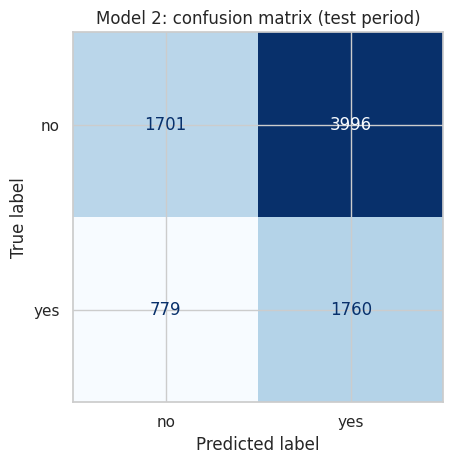

In [4]:
print(classification_report(y_test, y_pred, target_names=["no", "yes"], digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no", "yes"],
                                        cmap="Blues", colorbar=False)
plt.title("Model 2: confusion matrix (test period)")
plt.tight_layout(); plt.savefig("figures/model2_confusion_matrix.png", dpi=150); plt.show()

## 4. Cross-validation stability (training period)
5-fold stratified cross-validation AUC on the training period, reported as mean ± standard deviation. A small standard deviation means the model's performance is stable across different subsets of the data.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(clone(model), X_train, y_train, cv=cv, scoring="roc_auc")
pd.Series(cv_scores, index=[f"Fold {i}" for i in range(1, 6)]).to_csv("model2_decision_tree_cv_scores.csv", header=["ROC AUC"])
print("Fold AUCs:", np.round(cv_scores, 3))
print(f"Mean ± SD: {cv_scores.mean():.3f} ± {cv_scores.std(ddof=1):.3f}")

Fold AUCs: [0.665 0.659 0.67  0.663 0.666]
Mean ± SD: 0.665 ± 0.004


## 5. ROC curve, precision-recall curve and calibration

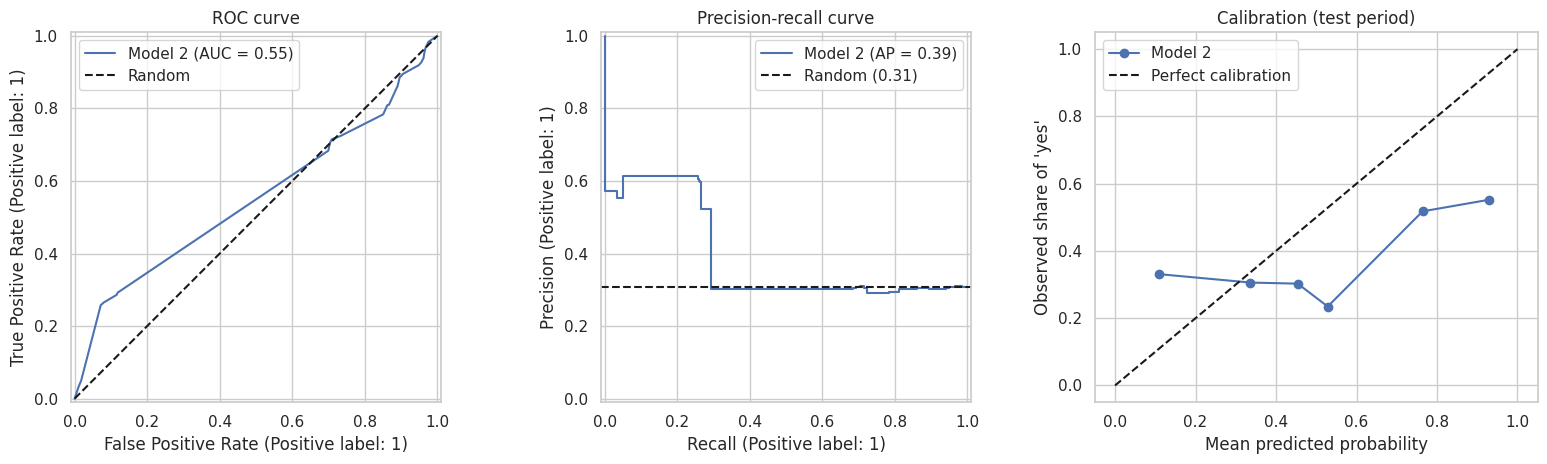

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
RocCurveDisplay.from_predictions(y_test, y_prob, name="Model 2", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random"); axes[0].legend(); axes[0].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, name="Model 2", ax=axes[1])
axes[1].axhline(y_test.mean(), color="k", ls="--", label=f"Random ({y_test.mean():.2f})")
axes[1].legend(); axes[1].set_title("Precision-recall curve")

frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, "o-", label="Model 2")
axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed share of 'yes'")
axes[2].set_title("Calibration (test period)"); axes[2].legend()
plt.tight_layout(); plt.savefig("figures/model2_curves.png", dpi=150); plt.show()

## 6. Cumulative gains and lift
Customers are ranked by predicted probability. The table shows what share of all converters is reached by contacting the top-ranked 10%, 20%, 30% and 50%, and the lift over random targeting (1.0 = no better than random).

In [7]:
gains_table(y_test, y_prob)

,Converters captured,Lift
Top share contacted,,
10%,0.193,1.93
20%,0.314,1.57
30%,0.421,1.40
50%,0.573,1.15


## 7. Threshold analysis
The default threshold of 0.5 is not necessarily the best choice. This table shows the trade-off between precision and recall at other thresholds.

In [8]:
threshold_table(y_test, y_prob)

,Share predicted 'yes',Precision,Recall,F1-Score,Accuracy
Threshold,,,,,
0.3,0.849,0.294,0.810,0.432,0.342
0.4,0.731,0.306,0.724,0.430,0.408
0.5,0.699,0.306,0.693,0.424,0.420
0.6,0.136,0.599,0.263,0.366,0.719
0.7,0.133,0.605,0.261,0.365,0.720


## 8. Robustness check: time-ordered vs random split
The same tuned model is retrained on a shuffled, stratified split. The gap between the two AUCs shows how much performance depends on the change in conditions over time.

In [9]:
X_all, y_all = pd.concat([X_train, X_test]), pd.concat([y_train, y_test])
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all,
                                              random_state=RANDOM_SEED)
random_auc = roc_auc_score(yr_te, clone(model).fit(Xr_tr, yr_tr).predict_proba(Xr_te)[:, 1])
pd.Series({"ROC AUC, time-ordered split": metrics.loc["ROC AUC", "Value"],
           "ROC AUC, random split": round(random_auc, 3)})

ROC AUC, time-ordered split    0.552
ROC AUC, random split          0.799
dtype: float64